In [208]:
# --- BLOCK 1: Imports and Single-Cluster Selection ---
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import adfuller
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

tickers = [
    'LLY', 'UNH', 'NVO', 'JNJ', 'MRK', 'ABBV', 'AZN', 'NVS', 'TMO', 'PFE', 'ABT', 'DHR',
    'JPM', 'BAC', 'WFC', 'GS', 'MS', 'C',
    'AAPL', 'MSFT', 'GOOGL', 'META'
]

print("Downloading initial data for clustering...")
initial_data = yf.download(tickers, start="2020-06-01", end="2023-06-01")['Close']
returns = initial_data.pct_change().dropna()

X = returns.T
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

dbscan = DBSCAN(eps=10, min_samples=2)
labels = dbscan.fit_predict(X_pca)

clusters_dict = {}
for cluster_id, ticker in zip(labels, X.index):
    if cluster_id != -1:
        clusters_dict.setdefault(cluster_id, []).append(ticker)

if not clusters_dict:
    raise ValueError("DBSCAN found no clusters. Increase the 'eps' parameter.")

print("\n--- All Valid Clusters Found ---")
for cid, members in clusters_dict.items():
    print(f"Cluster {cid}: {members}")

# Pick the exact cluster that gave you the 1% profit!
chosen_cluster_id = 1
stocks = clusters_dict[chosen_cluster_id]
print(f"\nSelected Cluster for Cointegration: {stocks}")

# Download pricing data specifically for the chosen cluster
stock_data = yf.download(stocks, start="2020-06-01", end="2023-06-01")['Close']

[*********             18%                       ]  4 of 22 completed

[*********************100%***********************]  22 of 22 completed
[*********************100%***********************]  5 of 5 completed


--- All Valid Clusters Found ---
Cluster 0: ['AAPL', 'GOOGL', 'MSFT']
Cluster 1: ['ABBV', 'JNJ', 'MRK', 'NVS', 'UNH']
Cluster 2: ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']
Cluster 3: ['DHR', 'TMO']

Selected Cluster for Cointegration: ['ABBV', 'JNJ', 'MRK', 'NVS', 'UNH']


In [209]:
# Applies the two-step Engle & Granger test for cointegration.
def step1(y, x):
    '''
    First fits the long-run relationship
    y_t = c + gamma * x_t + z_t
    z_t is the residual (error correction term)
    '''
    regression = OLS(y, add_constant(x), has_const=True)
    regression_fit = regression.fit()
    c, gamma = regression_fit.params
    z = regression_fit.resid
    return c, gamma, z
def step2(y, x):
    """
    Dickey-Fuller phi=1 vs phi < 1 in
    z_t = phi * z_(t-1) + eta_t

    If this implies phi < 1, the z series is stationary,
    and thus the series y and x are concluded to be cointegrated
    """
    c, gamma, z = step1(y, x)
    adfstat, pvalue, usedlag, nobs, crit_values = adfuller(z, maxlag=1, autolag=None)
    return adfstat, pvalue

In [210]:
# stocks = ['LLY',"UNH","NVO","JNJ","MRK","ABBV","AZN","NVS","TMO","PFE","ABT","DHR"]
# stock_data =  yf.download(stocks, start = "2017-06-01" ,end= "2020-06-01")['Adj Close']
# stock_data.head()

In [211]:
def coint(stock_data, stocks):
    data = {'Pairs': [],
                     'Constant': [],
                     'Gamma': [],
                     'P-Value': []}
    zvalues = {}

    for stock1 in stocks:
        for stock2 in stocks:
            if stock1 != stock2:
                pair = stock1, stock2
                c, gamma, zvalue = step1(np.log(stock_data[stock1]),np.log(stock_data[stock2]))
                t_stat, pvalue = step2(np.log(stock_data[stock1]),np.log(stock_data[stock2]))

                data['Pairs'].append(pair)
                data['Constant'].append(c)
                data['Gamma'].append(gamma)
                data['P-Value'].append(pvalue)
                zvalues[pair] = zvalue
    data = pd.DataFrame(data,index=pd.MultiIndex.from_tuples(data['Pairs']))
    data.drop('Pairs', axis=1, inplace=True)
    return data,pd.DataFrame(zvalues)

In [212]:
# Visualize the P-values
def plot_pvalues(coint_data):
    plt.figure(figsize=(20, 5))
    plt.hist(coint_data['P-Value'], bins=100)
    plt.xlabel('P-value')
    plt.ylabel('Number of observations')
    plt.title('All obtained P-values')
    plt.show()
    coint_mat = coint_data.unstack(level=0)['P-Value']
    coint_mat = coint_mat.fillna(1)
    plt.figure(figsize=(8, 6))  # Adjust the figure size as needed
    sns.heatmap(coint_mat, annot=True, cmap="YlGnBu")
    plt.title("Heatmap of Pairs")
    plt.show()

In [213]:
# coint_analysis,zvalues = coint(stock_data,stocks)
# print(coint_analysis.head())
# print(coint_analysis.tail())
# plot_pvalues(coint_analysis)

In [214]:
tradable_pairs = coint_analysis[coint_analysis['P-Value'] < 0.005].sort_values('P-Value')
tradable_pairs.head(10)

,,Constant,Gamma,P-Value
MS,WFC,0.976311,0.91271,0.004697


In [215]:
def select_stock_pair(stock_data,S1,S2):
    plt.figure(figsize=(20,5))
    plt.plot(np.log(stock_data[S1]),color="blue",label=S1)
    plt.plot(np.log(stock_data[S2]),color="black",label=S2)
    plt.xlabel('Time')
    plt.ylabel("Close Price")
    plt.legend()
    plt.show()
    c,gamma,zvalue = step1(np.log(stock_data[S1]),np.log(stock_data[S2]))
    plt.figure(figsize=(20,5))
    plt.title('Error-correction term (Spread)')
    zvalue.plot()
    plt.xlabel('Time')
    plt.ylabel('Magnitude')
    plt.axhline(0.05,color='g') # Note 0.005 is randomly chosen
    plt.axhline(0,color='black') # Note -0.005 is randomly chosen
    plt.axhline(-0.05,color='r') # Note -0.005 is randomly chosen
    plt.legend(['Z-Value', 'Positive Threshold', 'Negative Threshold'], loc='lower left')
    plt.show()
    return zvalue,gamma

In [216]:
# --- BLOCK 3: Strategy Function ---
def zscore(series, window_length=20):
    rolling_mean = series.rolling(window=window_length).mean()
    rolling_std = series.rolling(window=window_length).std()
    return (series - rolling_mean) / rolling_std

def strategy(S1, S2, threshold=1, stop_loss=0.5):
    # Testing period: 2023 - 2025
    strat = yf.download([S1, S2], start="2023-07-01", end="2025-07-01")['Close']

    # Restored to use 'stock_data'
    gamma = select_stock_pair(stock_data, S1, S2)[1]

    spread = np.log(strat[S1]) - gamma * np.log(strat[S2])
    strat['zscore'] = zscore(spread)

    strat['raw_signal'] = np.select([strat['zscore'] > threshold, strat['zscore'] < -threshold], [1, -1], default=0)

    strat.loc[abs(strat["zscore"]) > (threshold + stop_loss), "raw_signal"] = 0
    strat.loc[abs(strat["zscore"]) < 0.1, "raw_signal"] = 0

    strat['signal'] = strat['raw_signal'].shift(1).fillna(0)

    strat['position1'] = -strat['signal'].diff().fillna(0)
    strat['position2'] = -strat['position1']

    return strat, gamma

In [217]:
# def zscore(series,window_length=20):
#     zscores = []
#     for i in range(window_length, len(series)):
#       window = series[i-window_length:i]
#       zscores.append((series[i]-window.mean())/window.std())
#     return pd.Series(zscores, index = series.index[window_length:])

In [218]:
# def strategy(S1,S2,threshold=1,stop_loss=0.5):
#     strat = yf.download([S1,S2], start = "2020-07-01" ,end= "2023-07-01")['Adj Close']
#     gamma = select_stock_pair(stock_data,S1,S2)[1]
#     spread = np.log(strat[S1])-gamma*np.log(strat[S2])
#     strat['zscore'] = zscore(spread)
#     #Normal Signal
#     strat['signal'] = np.select([strat['zscore'] > threshold, strat['zscore'] < -threshold], [1, -1], default = 0)
#     # Stop loss
#     strat.loc[abs(strat["zscore"]) > threshold+stop_loss, "signal"] = 0
#     # Take profit
#     strat.loc[abs(strat["zscore"]) == 0, "signal"] = 0
#     strat['position1'] = -strat['signal'].diff()
#     strat['position2'] = -strat['position1']
#     strat=strat.fillna(0)
#     return strat, gamma

In [219]:
def visualize_strategy(strat):
    fig, axs = plt.subplots(3, sharex=True, figsize=(15,12))
    axs[0].set_title('Market Value')
    axs[0].plot(strat[S1],label=S1,color='black')
    axs[0].plot(strat[S1][strat['position1'] == 1], lw=0, marker='^', markersize=8, c='g',alpha=0.7)
    axs[0].plot(strat[S1][strat['position1'] == -1], lw=0, marker='^', markersize=8, c='r',alpha=0.7)
    axs[0].grid()
    axs[0].legend()
    axs[1].set_title('Market Value')
    axs[1].plot(strat[S2],label=S2,color='black')
    axs[1].plot(strat[S2][strat['position2'] == -1], lw=0, marker='^', markersize=8, c='g',alpha=0.7)
    axs[1].plot(strat[S2][strat['position2'] == 1], lw=0, marker='^', markersize=8, c='r',alpha=0.7)
    axs[1].grid()
    axs[1].legend()
    axs[2].set_title('Zscore')
    axs[2].plot(strat['zscore'])
    axs[2].grid()
    axs[2].axhline(2,color='g')
    axs[2].axhline(1,color='r')
    axs[2].axhline(0,color='black')
    axs[2].axhline(-1,color='g')
    axs[2].axhline(-2,color='r')
    axs[2].fill_between(strat.index,strat.zscore,1,where = strat.zscore >= 1, color = 'lightcoral')
    axs[2].fill_between(strat.index,strat.zscore,-1,where = strat.zscore <= -1, color = 'lightgreen')
    plt.show()

In [220]:
def pnl(strategy):
    initial_capital = 100000
    # dividing capital in ratio gamma:1
    C2 = initial_capital/(1+gamma)
    C1 = gamma*C2
    # Shares to buy for each stock
    shares1 = C1// (strategy[S1][0])
    shares2 = C2// (strategy[S2][0])
    portfolio = pd.DataFrame()
    #PnL for stock 1
    portfolio['return1'] = strat[S1].pct_change()*strat['signal']*shares1*100
    portfolio['total1'] = C1 + portfolio['return1'].cumsum()
    # PnL for stock 2
    portfolio['return2'] = -strat[S2].pct_change()*strat['signal']*shares2*100
    portfolio['total2'] = C2 + portfolio['return2'].cumsum()
    # Total PnL
    portfolio['total'] = portfolio['total1'] + portfolio['total2']
    portfolio = portfolio.dropna()
    plt.figure(figsize=(20,5))
    plt.grid()
    plt.title("Portfolio Value")
    plt.plot(portfolio['total'])
    plt.show()
    plt.figure(figsize=(20,5))
    plt.grid()
    plt.title("Daily PNL")
    plt.plot(100*portfolio['total'].pct_change())
    plt.show()
    return portfolio

In [221]:
def metrics(strategy):
    pft = pnl(strategy)
    # Calculating CAGR
    CAGR = (pft['total'][-1]/pft['total'][0])**(252/len(strat))-1
    # Calculating Sharpe Ratio
    r = 0.01
    mu = 100*pft['total'].pct_change() - r
    sharpe = np.sqrt(252)*mu.mean()/mu.std()
    # Calculating Drawdown
    highest = pft['total'].expanding().max()
    drawdown = 100*(highest - pft['total']) / highest
    max_drawdown = drawdown.max()

    print(f"Profit : {100*(pft['total'][-1]/pft['total'][0])-100} %")
    print(f"CAGR : {CAGR*100} %")
    print(f"Sharpe Ratio: {sharpe}")
    print(f"Maximum Drawdown: {max_drawdown}")
    print(f"Trades taken: {np.count_nonzero(strategy['position1'])}")

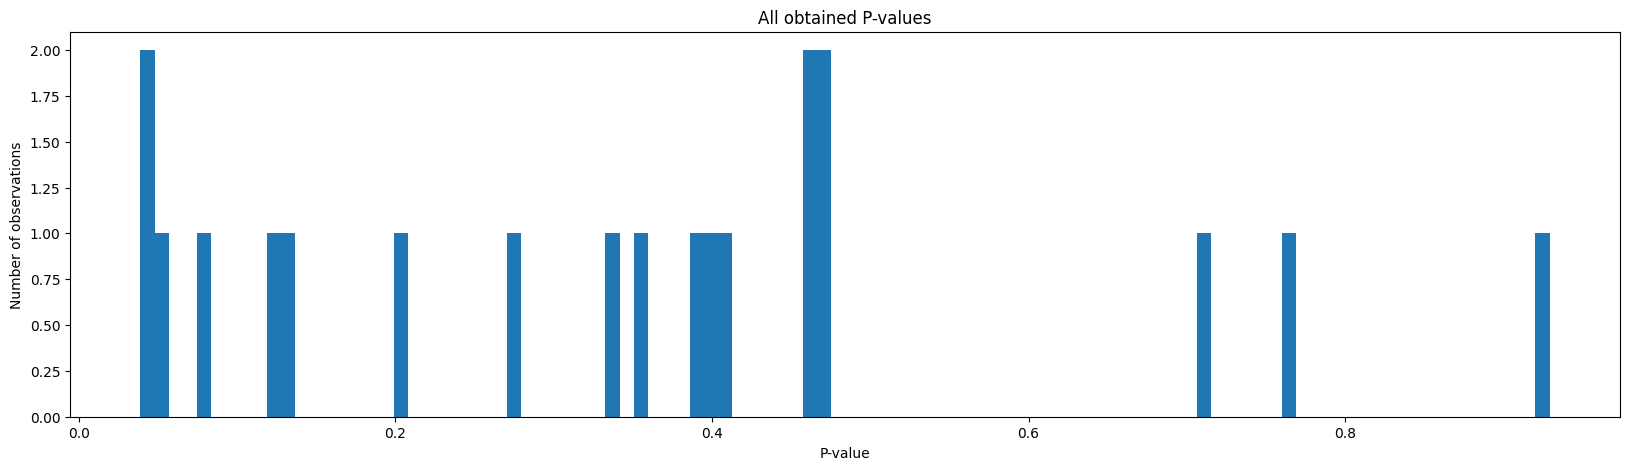

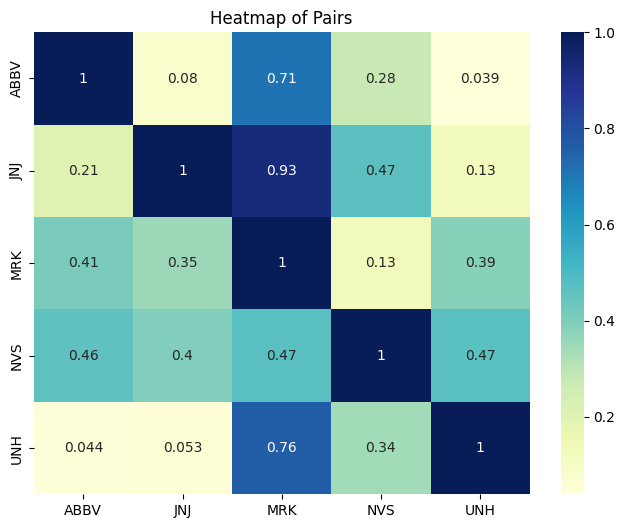

[                       0%                       ]


Top Tradable Pairs from Cluster:
           Constant     Gamma   P-Value
UNH  ABBV  2.071351  0.838661  0.039073
ABBV UNH  -1.656875  1.056205  0.044343
JNJ  UNH   2.900381  0.344987  0.053418
     ABBV  3.590774  0.294532  0.080241
UNH  JNJ  -5.000904  2.211900  0.126781

Running strategy on best statistical pair: UNH and ABBV


[*********************100%***********************]  2 of 2 completed


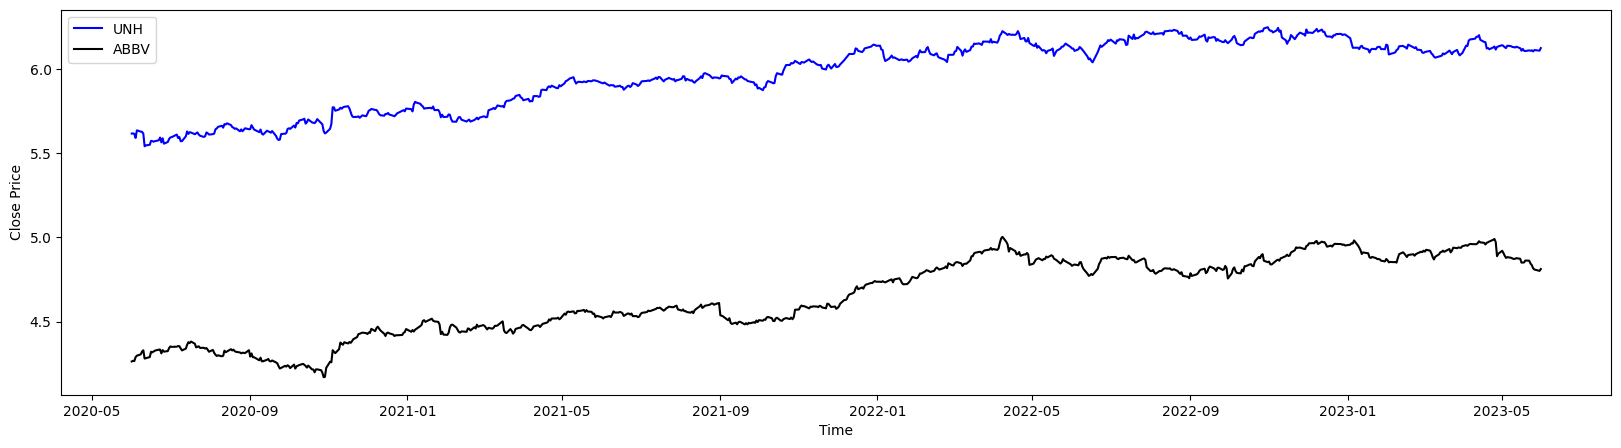

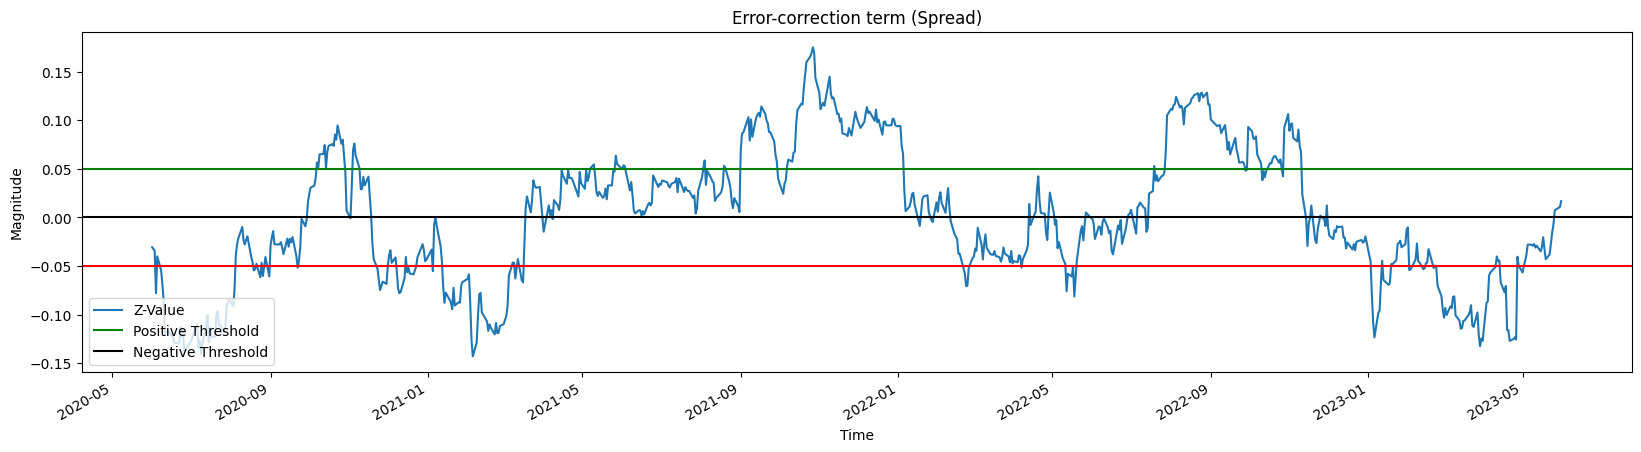

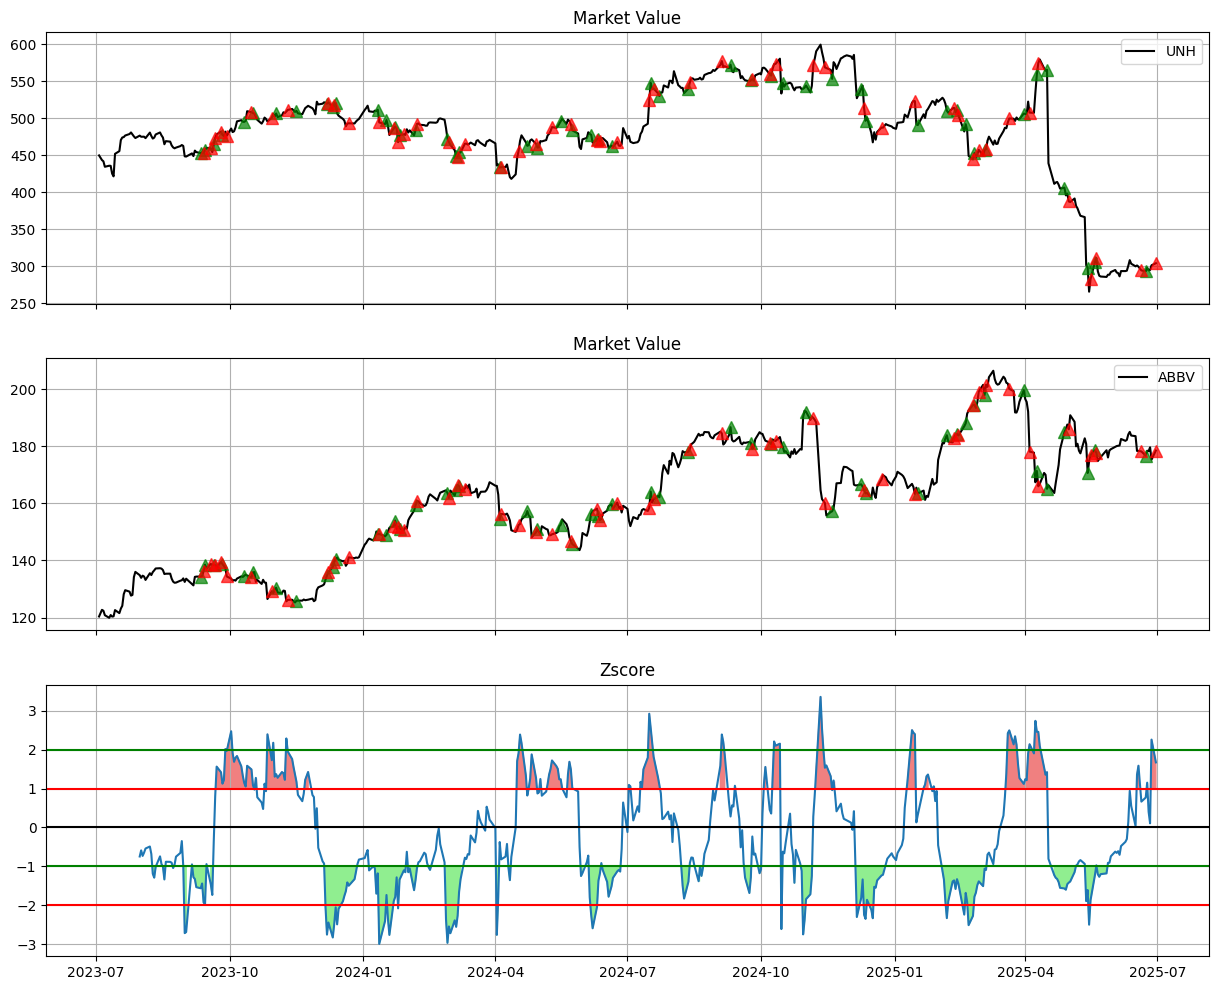

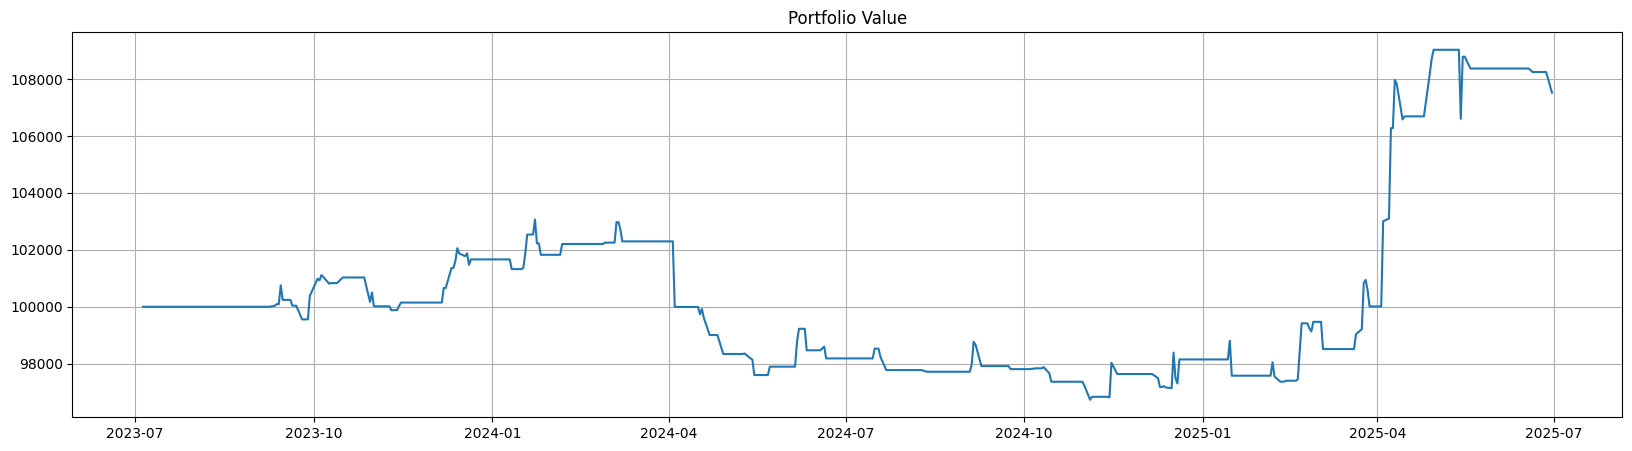

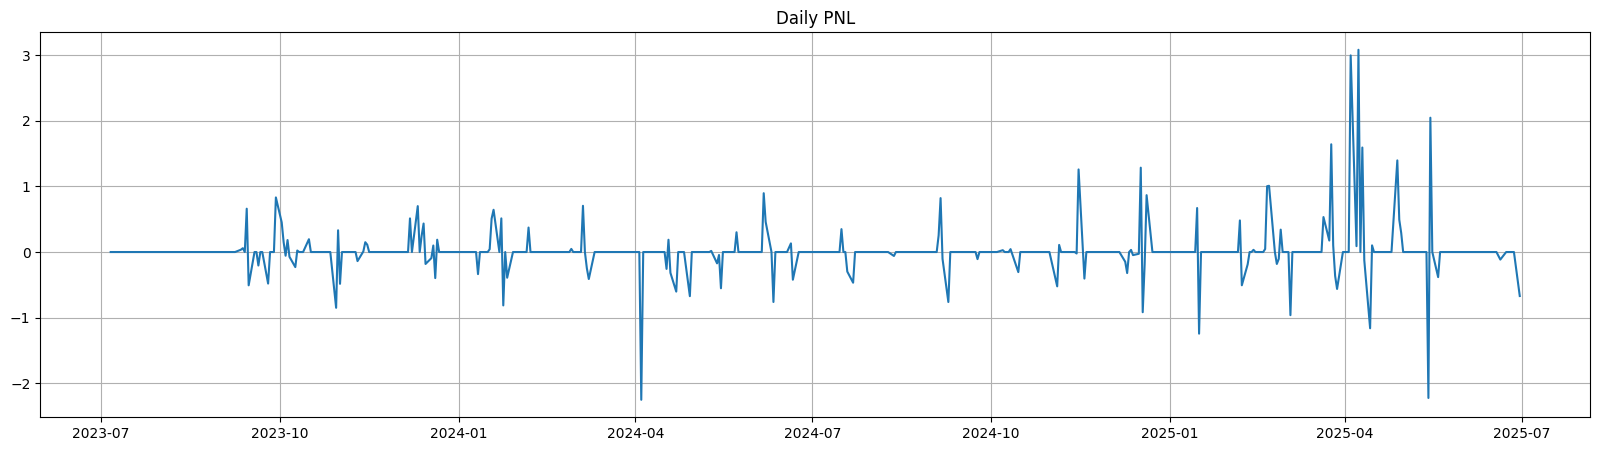

Profit : 7.52037861153066 %
CAGR : 3.722113027411633 %
Sharpe Ratio: 0.22719540881237446
Maximum Drawdown: 6.142707833566414
Trades taken: 103


In [222]:
# --- BLOCK 4: Dynamic Single-Cluster Execution ---
coint_analysis, zvalues = coint(stock_data, stocks)
plot_pvalues(coint_analysis)

# Filter for tradable pairs
tradable_pairs = coint_analysis[coint_analysis['P-Value'] < 0.2].sort_values('P-Value')
print("\nTop Tradable Pairs from Cluster:")
print(tradable_pairs.head())

if not tradable_pairs.empty:
    best_pair = tradable_pairs.index[0]
    S1 = best_pair[0]
    S2 = best_pair[1]
    print(f"\nRunning strategy on best statistical pair: {S1} and {S2}")

    # Tweaked the threshold/stop-loss to try and improve your 1% profit!
    strat, gamma = strategy(S1, S2, threshold=1.5, stop_loss=1.0)
    visualize_strategy(strat)
    metrics(strat)
else:
    print("No cointegrated pairs found in this cluster.")

In [223]:
# S1 = 'TMO'
# S2 = 'AZN'
# strat, gamma = strategy(S1,S2,1,1)

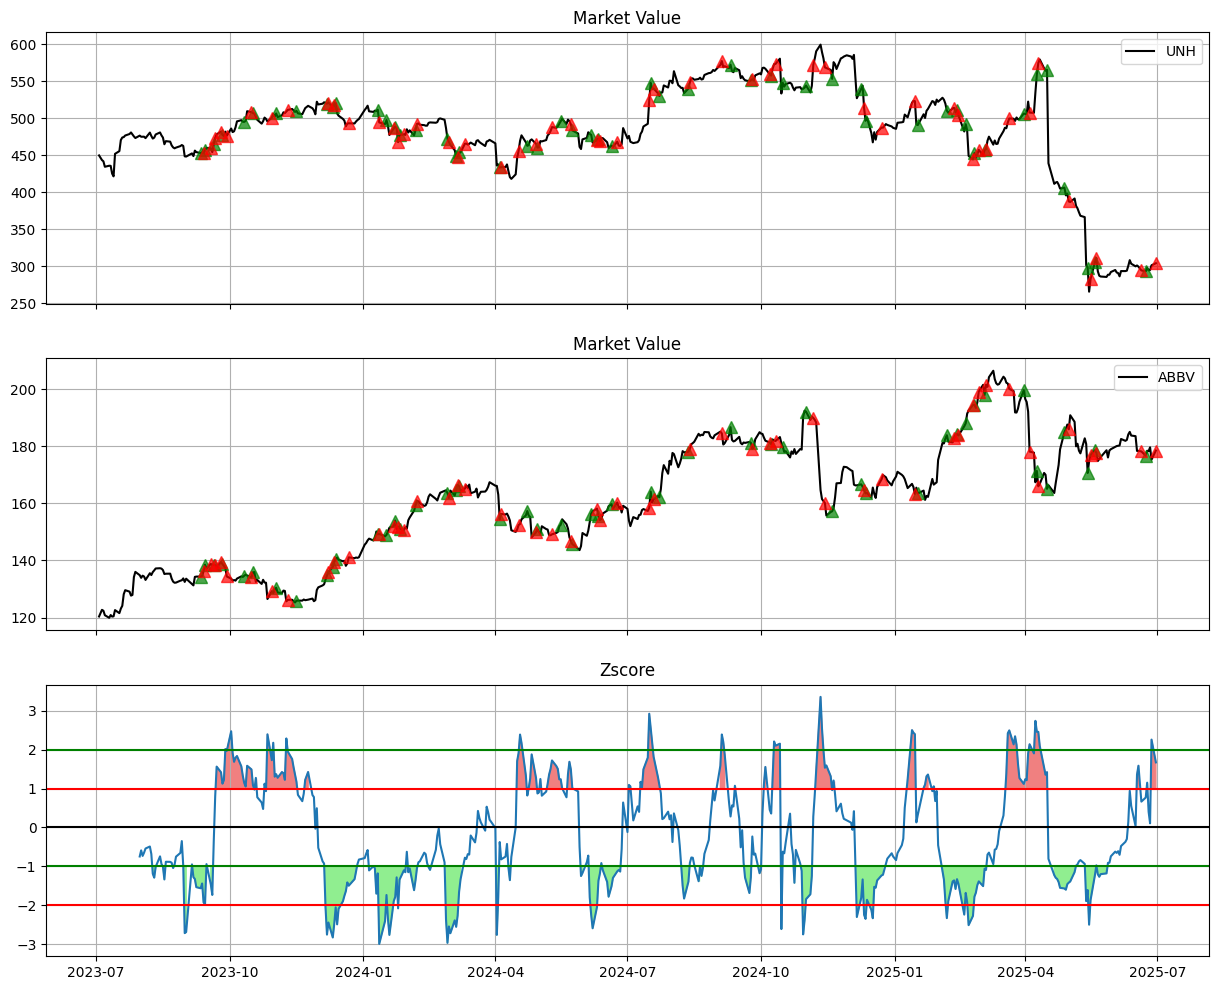

In [224]:
visualize_strategy(strat)

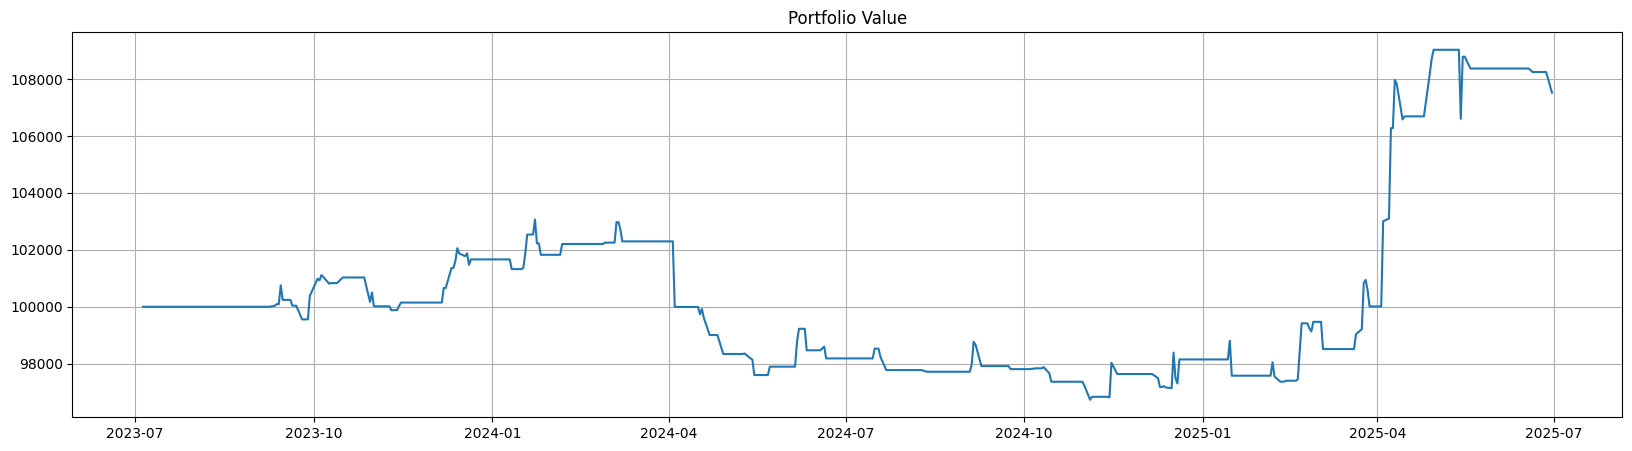

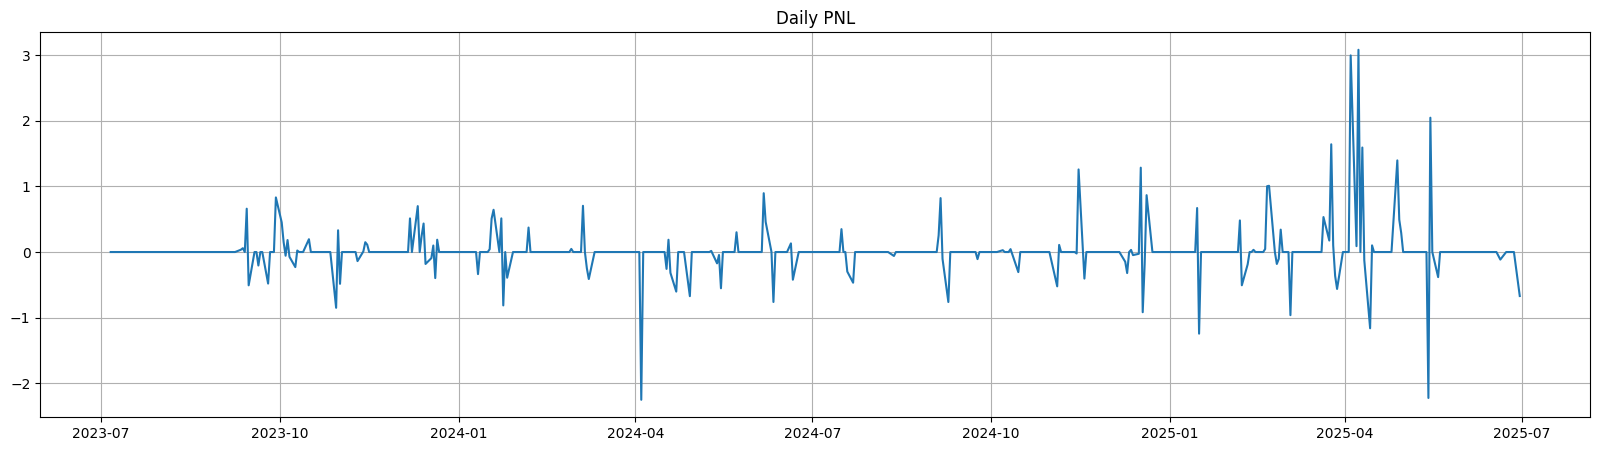

Profit : 7.52037861153066 %
CAGR : 3.722113027411633 %
Sharpe Ratio: 0.22719540881237446
Maximum Drawdown: 6.142707833566414
Trades taken: 103


In [225]:
metrics(strat)